In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import numpy as np
import pandas as pd
import h5py

import pycbc.conversions, pycbc.distributions, pycbc.waveform, pycbc.filter, pycbc.types, pycbc.psd, pycbc.fft

from tqdm import tqdm
import multiprocessing

from pyseobnr.generate_waveform import GenerateWaveform as eob_td_wf
from matplotlib import pyplot as plt

In [20]:
class GenWaveform(object):
    '''Waveform Generator
    '''
    def __init__(self, buffer_length, sample_rate, f_lower):
        self.f_lower = f_lower
        self.delta_f = 1.0 / buffer_length
        tlen = int(buffer_length * sample_rate) # buffer length x sample_rate
        self.flen = tlen // 2 + 1

        #psd is hard coded to O3 psd
        psd = pycbc.psd.read.from_txt('/work/yifanwang/ecc/templatebank/o3psd.txt', 
            self.flen, self.delta_f, self.f_lower, is_asd_file = False)
        
        self.kmin = int(f_lower * buffer_length)
        self.w = ((1.0 / psd[self.kmin:-1]) ** 0.5).astype(np.float32)
        
        qtilde = pycbc.types.zeros(tlen, np.complex64) # correlation in Fourier domain
        q = pycbc.types.zeros(tlen, np.complex64) # correlation
        self.qtilde_view = qtilde[self.kmin:self.flen - 1]
        self.ifft = pycbc.fft.IFFT(qtilde, q)
        
        # the maximum is around 0
        self.md = q._data[-100:]
        self.md2 = q._data[0:100] 

    def generate(self, **kwds):
        '''Return normalized hp
        '''
        if kwds['approximant'] in pycbc.waveform.fd_approximants():  
            hp, _ = pycbc.waveform.get_fd_waveform(delta_f = self.delta_f, **kwds)
        else:
            dt = 1.0 / self.sample_rate
            hp = pycbc.waveform.get_waveform_filter(
                        pycbc.types.zeros(self.flen, dtype=np.complex64),
                        delta_f=self.delta_f,
                        delta_t=dt,
                        f_lower=self.f_lower,
                        **kwds)
        
        hp.resize(self.flen)
        hp = hp.astype(np.complex64)
        
        hp[self.kmin:-1] *= self.w
        s = pycbc.filter.sigmasq(hp, low_frequency_cutoff=self.f_lower)
        hp /= s**0.5 
        
        hp.params = kwds
        hp.s = s

        return hp

    def match(self, hp, hc):
        hp.view = hp[self.kmin:-1]
        hc.view = hc[self.kmin:-1]
        pycbc.filter.correlate(hp.view, hc.view, self.qtilde_view)
        self.ifft.execute()
        m = max(abs(self.md).max(), abs(self.md2).max())
        return m * 4.0 * self.delta_f

    def overlap(self, hp, hc):
        o = hp.inner(hc)
        return o * 4.0 * self.delta_f
    
def wf_wrapper(p):
    index = p['index']
    try:
        hp = gen.generate(**p)
        return index, hp
    except Exception as e:
        print(e)
        return index, None

def match_wrapper(p):
    '''A wrapper function to compute match
    '''
    h1 =pycbc.types.FrequencySeries(initial_array=p['h1_data'], delta_f=p['h1_delta_f'])
    h2 =pycbc.types.FrequencySeries(initial_array=p['h2_data'], delta_f=p['h2_delta_f'])
    return p['bank_index'], gen.match(h1, h2)

def gen_injections():
    mass_lim = (5, 100)
    spin_lim = (-0.5, 0.5)
    ecc_lim = (0, 0.3)
    ano_lim = (0, 2*np.pi)

    uniform_prior = pycbc.distributions.Uniform(
                            mass1=mass_lim,
                            mass2=mass_lim,
                            spin1z=spin_lim,
                            spin2z=spin_lim,
                            eccentricity=ecc_lim,
                            rel_anomaly=ano_lim)

    def _q_lt_8(params):
        return pycbc.conversions.q_from_mass1_mass2(params["mass1"],params["mass2"]) < 8

    return pycbc.distributions.JointDistribution(["mass1",
                                "mass2",
                                "spin1z",
                                "spin2z",
                                "eccentricity",
                                "rel_anomaly"],
                                uniform_prior,
                                constraints=[_q_lt_8])

def tdwf_wrapper(p):
    p2 = {"approximant": "SEOBNRv5EHM",
          "ModeArray": [(2,2)],
          "f22_start": 20,
          "lmax_nyquist": 1
         }
    p.update(p2)
    index = p['index']
    try:
        wf = eob_td_wf(p)
        hp, _ = wf.generate_td_polarizations()
        return index, abs(float(hp.epoch))
    except Exception as e:
        print(e)
        return index, None

def tdwf(p):
    p2 = {"approximant": "SEOBNRv5EHM",
          "ModeArray": [(2,2)],
          "f22_start": 20,
          "lmax_nyquist": 1
         }
    p.update(p2)
    index = p['index']
    try:
        wf = eob_td_wf(p)
        hp, _ = wf.generate_td_polarizations()
        return index, hp
    except Exception as e:
        print(e)
        return index, None


In [3]:
gen = GenWaveform(buffer_length = 32, sample_rate = 2048, f_lower = 20)

Read in template bank

In [4]:
with h5py.File('/work/yifanwang/ecc/src/searchtools/scripts/sucbankprodduration.hdf') as f:
        df_bank = pd.DataFrame(
           {'mass1': f['mass1'][:],
            'mass2': f['mass2'][:],
            'tau0': pycbc.conversions.tau0_from_mass1_mass2(f['mass1'][:],f['mass2'][:],15),
            'eccentricity': f['eccentricity'][:],
            'rel_anomaly': f['rel_anomaly'][:],
            'spin1z': f['spin1z'][:],
            'spin2z': f['spin2z'][:],
            'approximant': f['approximant'][:].astype('str'),
            'f_lower': f['f_lower'][:],
            'template_duration': f['template_duration'][:],}
        )
df_bank['index'] = df_bank.index

In [5]:
df_bank

,mass1,mass2,tau0,eccentricity,rel_anomaly,spin1z,spin2z,approximant,f_lower,template_duration,index
0,64.061093,85.262889,0.459226,0.167525,1.997884,0.000620,-0.081165,SEOBNRv5E,20.0,0.141113,0
1,68.060491,28.587619,1.115139,0.259024,2.260746,0.176357,-0.226991,SEOBNRv5E,20.0,0.329590,1
2,59.947013,61.584384,0.634350,0.031182,1.161729,0.481824,0.420913,SEOBNRv5E,20.0,0.286133,2
3,43.772996,61.903602,0.824914,0.291899,2.723562,-0.367094,0.328200,SEOBNRv5E,20.0,0.228516,3
4,59.499551,76.280133,0.535416,0.234504,1.573280,0.164777,-0.268736,SEOBNRv5E,20.0,0.150879,4
...,...,...,...,...,...,...,...,...,...,...,...
730282,5.025893,5.011645,40.490520,0.179931,3.562414,-0.170420,-0.087774,SEOBNRv5E,20.0,16.978027,730282
730283,5.020360,5.006370,40.563286,0.295819,1.262575,0.365476,0.431696,SEOBNRv5E,20.0,14.226562,730283
730284,5.001911,5.000287,40.729157,0.150412,0.685238,0.282719,0.463015,SEOBNRv5E,20.0,18.084473,730284
730285,5.013018,5.012965,40.568248,0.172876,3.767090,0.117018,-0.025586,SEOBNRv5E,20.0,17.303223,730285


Study #6

In [6]:
df = pd.read_csv('figure/studymatch/injections.csv')

In [40]:
parlist = ['index', 'approximant', 'f_lower', 'mass1', 'mass2', 'spin1z', 'spin2z', 'eccentricity', 'rel_anomaly']
_, hf = wf_wrapper({k: df.loc[6,k] for k in parlist})
_, eob = tdwf({k: df.loc[6,k] for k in parlist})

In [41]:
ht = hf.to_timeseries()

In [42]:
from pycbc.types import TimeSeries

In [43]:
heob = TimeSeries(eob.data.data, delta_t=1/2048, epoch=eob.epoch)

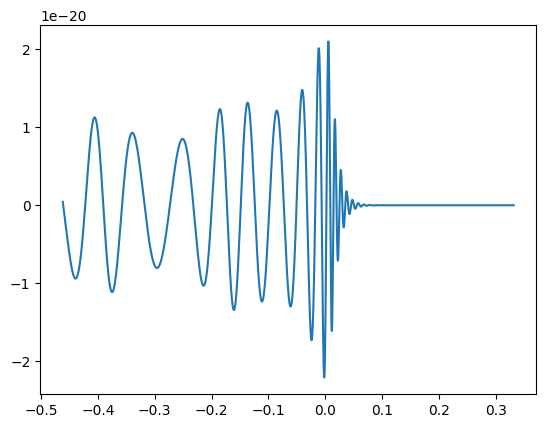

In [48]:
#plt.plot(ht.sample_times, ht)
#plt.xlim(-0.5,)
plt.plot(heob.sample_times, heob)

In [49]:
dfff = pd.read_csv('figure/studymatch/FF_6.csv')

In [53]:
_ , hbank = tdwf({k: dfff.loc[0,k] for k in parlist})

In [54]:
hbank = TimeSeries(hbank.data.data, delta_t=1/2048, epoch=hbank.epoch)

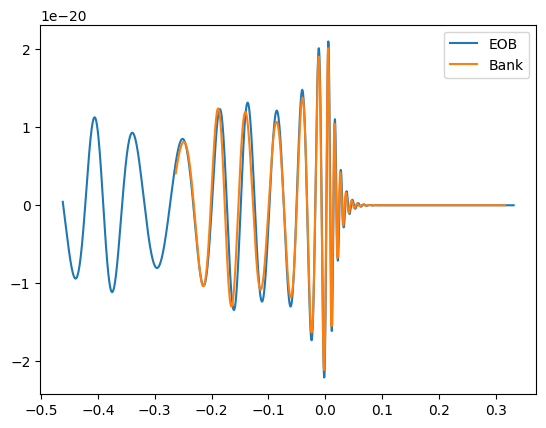

In [57]:
plt.plot(heob.sample_times, heob, label='EOB')
plt.plot(hbank.sample_times, hbank,label='Bank')
plt.legend()

In [58]:
{k: df.loc[6,k] for k in parlist}

{'index': 6,
 'approximant': 'SEOBNRv5E',
 'f_lower': 20.0,
 'mass1': 95.89573620890783,
 'mass2': 90.9704931798746,
 'spin1z': 0.0455565716226549,
 'spin2z': 0.1598230517736367,
 'eccentricity': 0.1017319442552542,
 'rel_anomaly': 2.406399102089125}

In [59]:
{k: dfff.loc[0,k] for k in parlist}

{'index': 13986,
 'approximant': 'SEOBNRv5E',
 'f_lower': 20.0,
 'mass1': 95.87712058372628,
 'mass2': 84.01798837391283,
 'spin1z': -0.0098297512320939,
 'spin2z': 0.1299038236226795,
 'eccentricity': 0.1315863192636969,
 'rel_anomaly': 2.6260074961726185}